In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('fraud.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280499 entries, 0 to 1280498
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1280499 non-null  int64  
 1   type            1280499 non-null  object 
 2   amount          1280499 non-null  float64
 3   nameOrig        1280499 non-null  object 
 4   oldbalanceOrg   1280498 non-null  float64
 5   newbalanceOrig  1280498 non-null  float64
 6   nameDest        1280498 non-null  object 
 7   oldbalanceDest  1280498 non-null  float64
 8   newbalanceDest  1280498 non-null  float64
 9   isFraud         1280498 non-null  float64
 10  isFlaggedFraud  1280498 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 107.5+ MB


In [ ]:
print(df['isFraud'].value_counts())
print(f"\nFraud percentage: {df['isFraud'].mean() * 100:.2f}%")

isFraud
0.0    1278956
1.0       1542
Name: count, dtype: int64

Fraud percentage: 0.12%


In [ ]:
print(df.groupby('type')['isFraud'].sum())


type
CASH_IN       0.0
CASH_OUT    778.0
DEBIT         0.0
PAYMENT       0.0
TRANSFER    764.0
Name: isFraud, dtype: float64


In [ ]:
df = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])]
print(f"Remaining rows: {len(df)}")
print(f"Fraud percentage after filter: {df['isFraud'].mean() * 100:.2f}%")

Remaining rows: 561913
Fraud percentage after filter: 0.27%


In [ ]:
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df['type'] = df['type'].map({'CASH_OUT': 0, 'TRANSFER': 1})

print(df[['errorBalanceOrig', 'errorBalanceDest', 'type']].head())

    errorBalanceOrig  errorBalanceDest  type
2               0.00             181.0     1
3               0.00           21363.0     0
15         213808.94          182703.5     0
19         214605.30          237735.3     1
24         300850.89        -2401220.0     1


In [ ]:
features = ['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest',
            'errorBalanceOrig', 'errorBalanceDest']

X = df[features]
y = df['isFraud']

# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Fraud in training: {y_train.sum()}")
print(f"Fraud in testing: {y_test.sum()}")

Training samples: 449530
Testing samples: 112383
Fraud in training: 1234.0
Fraud in testing: 308.0


In [ ]:
from xgboost import XGBClassifier

# scale_pos_weight handles class imbalance
# ratio of non-fraud to fraud
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc'
)

model.fit(X_train, y_train)
print("Model trained successfully!")

scale_pos_weight: 363.29
Model trained successfully!


In [ ]:
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)
import numpy as np

# Get predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

AUC-ROC Score: 0.9944

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    112075
         1.0       0.80      0.98      0.88       308

    accuracy                           1.00    112383
   macro avg       0.90      0.99      0.94    112383
weighted avg       1.00      1.00      1.00    112383

Confusion Matrix:
[[111999     76]
 [     5    303]]


Model saved!


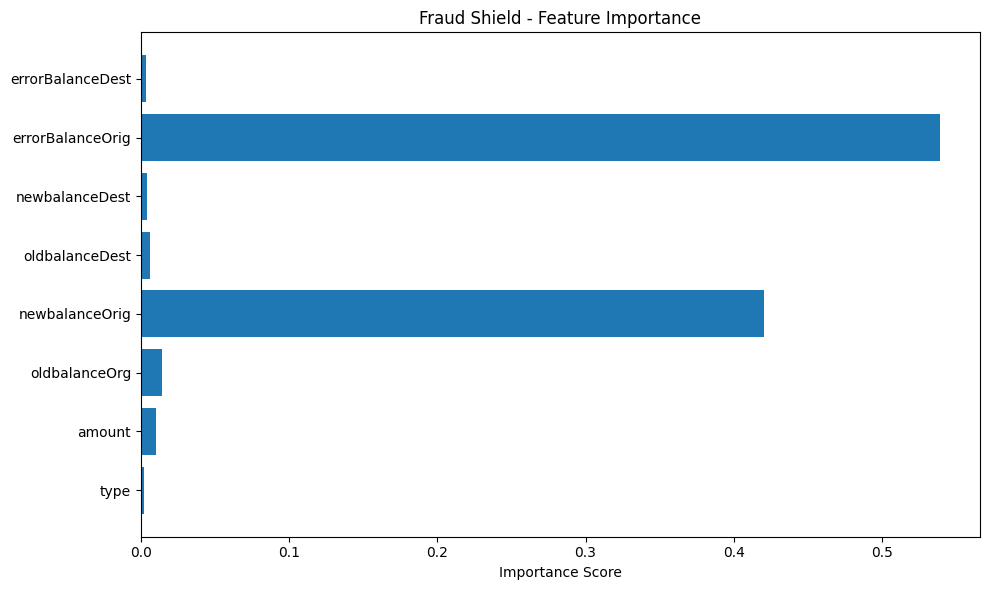

In [ ]:
import matplotlib.pyplot as plt

# Save model
import joblib
joblib.dump(model, 'fraud_shield_model.pkl')
print("Model saved!")

# Feature importance
plt.figure(figsize=(10, 6))
feat_importance = model.feature_importances_
feat_names = features
plt.barh(feat_names, feat_importance)
plt.title('Fraud Shield - Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# Install fastapi and uvicorn in colab
!pip install fastapi uvicorn nest-asyncio pyngrok -q
print("Done!")

Done!


In [ ]:
# Create the FastAPI app
app_code = """
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(title="Fraud Shield API")

# Load model
model = joblib.load('fraud_shield_model.pkl')

# Input schema
class Transaction(BaseModel):
    type: int  # 0=CASH_OUT, 1=TRANSFER
    amount: float
    oldbalanceOrg: float
    newbalanceOrig: float
    oldbalanceDest: float
    newbalanceDest: float
    errorBalanceOrig: float
    errorBalanceDest: float

@app.get("/")
def home():
    return {"message": "Fraud Shield API is running"}

@app.post("/predict")
def predict(transaction: Transaction):
    features = [[
        transaction.type,
        transaction.amount,
        transaction.oldbalanceOrg,
        transaction.newbalanceOrig,
        transaction.oldbalanceDest,
        transaction.newbalanceDest,
        transaction.errorBalanceOrig,
        transaction.errorBalanceDest
    ]]

    prediction = model.predict(features)[0]
    probability = model.predict_proba(features)[0][1]

    return {
        "is_fraud": bool(prediction),
        "fraud_probability": round(float(probability), 4),
        "risk_level": "HIGH" if probability > 0.7 else "MEDIUM" if probability > 0.3 else "LOW"
    }
"""

# Write to file
with open('main.py', 'w') as f:
    f.write(app_code)
print("FastAPI app created!")

FastAPI app created!


In [ ]:
import nest_asyncio
import uvicorn
import threading
import requests

nest_asyncio.apply()

# Start FastAPI in background
config = uvicorn.Config("main:app", port=8000, log_level="error")
server = uvicorn.Server(config)

thread = threading.Thread(target=server.run)
thread.daemon = True
thread.start()

import time
time.sleep(2)
print("Fraud Shield API is running!")

# Test with a FRAUDULENT transaction
fraud_transaction = {
    "type": 1,
    "amount": 500000.0,
    "oldbalanceOrg": 500000.0,
    "newbalanceOrig": 0.0,
    "oldbalanceDest": 0.0,
    "newbalanceDest": 0.0,
    "errorBalanceOrig": 0.0,
    "errorBalanceDest": 500000.0
}

response = requests.post("http://localhost:8000/predict", json=fraud_transaction)
print("\nFraudulent Transaction Test:")
print(response.json())

# Test with a LEGITIMATE transaction
legit_transaction = {
    "type": 0,
    "amount": 1000.0,
    "oldbalanceOrg": 5000.0,
    "newbalanceOrig": 4000.0,
    "oldbalanceDest": 2000.0,
    "newbalanceDest": 3000.0,
    "errorBalanceOrig": 0.0,
    "errorBalanceDest": 0.0
}

response = requests.post("http://localhost:8000/predict", json=legit_transaction)
print("\nLegitimate Transaction Test:")
print(response.json())

Fraud Shield API is running!

Fraudulent Transaction Test:
{'is_fraud': True, 'fraud_probability': 0.9999, 'risk_level': 'HIGH'}

Legitimate Transaction Test:
{'is_fraud': False, 'fraud_probability': 0.0003, 'risk_level': 'LOW'}
